# Random Forest Regression

## Introduction
This notebook predicts the continuous target in the original Diabetes dataset. It starts from loading the CSV and preparing the data, then compares Decision Tree, Random Forest, Extra Trees, and Gradient Boosting models.

The notebook also uses RandomizedSearchCV to tune ensemble models. Model selection uses cross-validation on the training data; the test set is kept for final evaluation.

##  Import libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##  Load the dataset

In [39]:
df = pd.read_csv("../Dataset/diabetes.csv")
display(df.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


##  Inspect the dataset

In [40]:
df.shape

(442, 11)

In [41]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='str')

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [43]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


In [44]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

## features and target

In [45]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Features:
    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0

Target:
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64


### Test-Train Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


In [47]:
train_data = X_train.copy()
train_data["target"] = y_train
correlation = train_data.corr()["target"].sort_values(ascending=False)
print(correlation)

target    1.000000
bmi       0.604751
s5        0.552183
bp        0.444770
s4        0.425094
s6        0.390363
s1        0.199547
age       0.196510
s2        0.154922
sex       0.007116
s3       -0.384000
Name: target, dtype: float64


### Feature selection

In [48]:
X_train = X_train.drop(columns=["sex"])
X_test = X_test.drop(columns=["sex"])
print("Training features:")
print(X_train.columns)
print("\nNumber of features:", X_train.shape[1])

Training features:
Index(['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='str')

Number of features: 9


## Evaluation metrics

In [50]:
def get_metrics(name, model, cv_scores=None):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    row = {
        "Model": name,
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "MSE": mean_squared_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    }
    if cv_scores is not None:
        row["CV Mean R²"] = np.mean(cv_scores)
        row["CV Std R²"] = np.std(cv_scores)
    return row
cv = KFold(n_splits=5, shuffle=True, random_state=42)

##  Train baseline models

In [51]:
baseline_models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Baseline Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "Baseline Extra Trees": ExtraTreesRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "Baseline Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.03, max_depth=2,
        min_samples_leaf=5, random_state=42
    )
}
fitted_baselines = {}
baseline_rows = []
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    fitted_baselines[name] = model
    scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1
    )
    baseline_rows.append(get_metrics(name, model, scores))
baseline_results = pd.DataFrame(baseline_rows).sort_values(
    "CV Mean R²", ascending=False
)
display(baseline_results.round(4))

,Model,Train R²,Test R²,MAE,MSE,RMSE,CV Mean R²,CV Std R²
2,Baseline Extra Trees,1.0000,0.4338,43.5644,3000.0190,54.7724,0.4268,0.0443
3,Baseline Gradient Boosting,0.5891,0.4778,42.7258,2766.6486,52.5989,0.4140,0.0479
1,Baseline Random Forest,0.9242,0.4223,44.8503,3060.7640,55.3242,0.4107,0.0668
0,Decision Tree,1.0000,0.0751,55.6966,4900.4607,70.0033,-0.0710,0.2380


## Tune Random Forest using RandomizedSearchCV

In [52]:
rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": [1.0, "sqrt", 0.7, 0.9],
    "max_samples": [0.6, 0.8, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=rf_params,
    n_iter=30,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print("Best CV R²:", round(rf_search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_samples': 0.6, 'max_features': 'sqrt', 'max_depth': 10}
Best CV R²: 0.4485


## Tune Extra Trees

In [53]:
et_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": [1.0, "sqrt", 0.7, 0.9],
    "max_samples": [0.6, 0.8, 1.0]
}

et_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(
        random_state=42, n_jobs=1, bootstrap=True
    ),
    param_distributions=et_params,
    n_iter=20,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    random_state=43,
    refit=True,
    verbose=1
)

et_search.fit(X_train, y_train)
best_et = et_search.best_estimator_

print("Best Extra Trees parameters:")
print(et_search.best_params_)
print("Best CV R²:", round(et_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Extra Trees parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_samples': 0.8, 'max_features': 1.0, 'max_depth': 15}
Best CV R²: 0.4608


##  Tune Gradient Boosting

In [54]:
gb_params = {
    "n_estimators": [50, 100, 150, 200, 300],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.1],
    "max_depth": [1, 2, 3],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [2, 4, 6, 10],
    "subsample": [0.6, 0.8, 1.0],
    "loss": ["squared_error", "huber"]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_params,
    n_iter=20,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    random_state=44,
    refit=True,
    verbose=1
)

gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_

print("Best Gradient Boosting parameters:")
print(gb_search.best_params_)
print("Best CV R²:", round(gb_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Gradient Boosting parameters:
{'subsample': 0.6, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_depth': 1, 'loss': 'huber', 'learning_rate': 0.03}
Best CV R²: 0.448


##  Compare all models

In [55]:
all_models = {
    **fitted_baselines,
    "Tuned Random Forest": best_rf,
    "Tuned Extra Trees": best_et,
    "Tuned Gradient Boosting": best_gb
}

rows = []
for name, model in all_models.items():
    scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1
    )
    rows.append(get_metrics(name, model, scores))

results_df = pd.DataFrame(rows).sort_values(
    "CV Mean R²", ascending=False
).reset_index(drop=True)

display(results_df.round(4))

,Model,Train R²,Test R²,MAE,MSE,RMSE,CV Mean R²,CV Std R²
0,Tuned Extra Trees,0.7950,0.4789,42.5864,2760.8111,52.5434,0.4608,0.0249
1,Tuned Random Forest,0.6838,0.4778,43.2420,2766.8891,52.6012,0.4485,0.0159
2,Tuned Gradient Boosting,0.5649,0.4764,41.9115,2773.9998,52.6688,0.4480,0.0437
3,Baseline Extra Trees,1.0000,0.4338,43.5644,3000.0190,54.7724,0.4268,0.0443
4,Baseline Gradient Boosting,0.5891,0.4778,42.7258,2766.6486,52.5989,0.4140,0.0479
5,Baseline Random Forest,0.9242,0.4223,44.8503,3060.7640,55.3242,0.4107,0.0668
6,Decision Tree,1.0000,0.0751,55.6966,4900.4607,70.0033,-0.0710,0.2380


## Select a final model

In [56]:
best_name = results_df.loc[0, "Model"]
best_model = all_models[best_name]
y_pred_final = best_model.predict(X_test)

print("Selected model:", best_name)
print("CV Mean R²:", round(results_df.loc[0, "CV Mean R²"], 4))
print("Test R²:", round(r2_score(y_test, y_pred_final), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred_final), 4))
print("MSE:", round(mean_squared_error(y_test, y_pred_final), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_final)), 4))

Selected model: Tuned Extra Trees
CV Mean R²: 0.4608
Test R²: 0.4789
MAE: 42.5864
MSE: 2760.8111
RMSE: 52.5434


##  Compare test R²

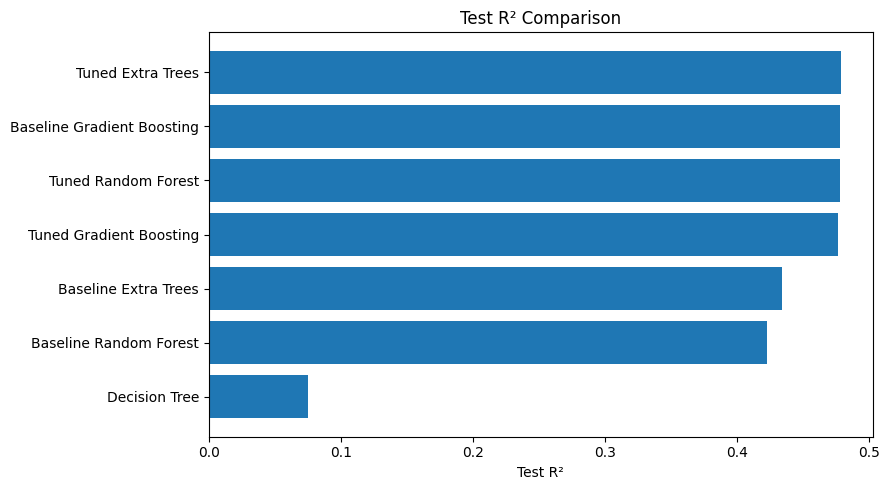

In [58]:
plot_data = results_df.sort_values("Test R²")
plt.figure(figsize=(9, 5))
plt.barh(plot_data["Model"], plot_data["Test R²"])
plt.xlabel("Test R²")
plt.title("Test R² Comparison")
plt.tight_layout()
plt.show()

##  Feature importance

,Feature,Importance
1,bmi,0.307723
7,s5,0.213643
2,bp,0.117657
6,s4,0.083109
8,s6,0.071442
5,s3,0.065262
0,age,0.051537
4,s2,0.045126
3,s1,0.044502


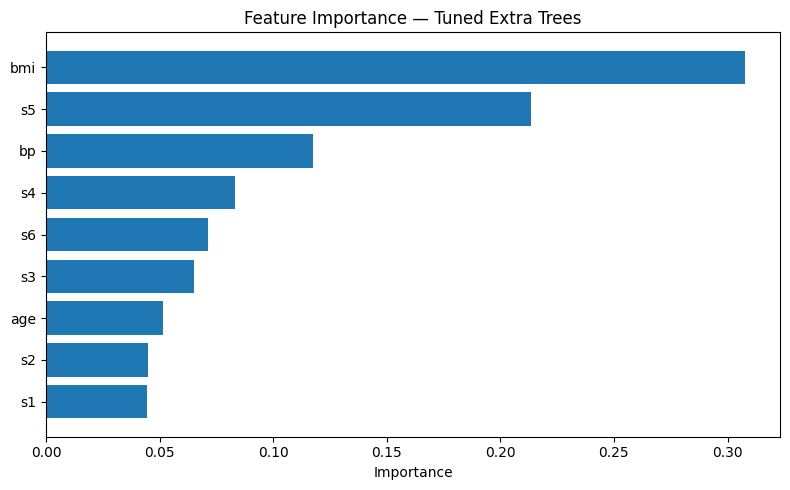

In [59]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance)

    plt.figure(figsize=(8, 5))
    plt.barh(importance["Feature"], importance["Importance"])
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.title(f"Feature Importance — {best_name}")
    plt.tight_layout()
    plt.show()
else:
    print("The selected model does not provide feature_importances_.")